# Notebook 03 — Modelo Principal: Random Forest (Bagging)

**Proyecto:** Predicción de Churn en Telecomunicaciones  

En este notebook entrenamos y evaluamos un **Random Forest Classifier**, que es un método de ensemble basado en la técnica de **Bagging** (Bootstrap Aggregating). Realizamos búsqueda de hiperparámetros con **GridSearchCV** y evaluamos el modelo con múltiples métricas.

## 1. Fundamento teórico: Bagging y Random Forest

### ¿Qué es Bagging (Bootstrap Aggregating)?

**Bagging** es una técnica de ensemble que entrena múltiples modelos independientes sobre subconjuntos aleatorios del dataset de entrenamiento, generados mediante **muestreo con reemplazo** (bootstrap). Las predicciones finales se obtienen por **votación mayoritaria** (clasificación) o **promedio** (regresión).

**¿Por qué reduce la varianza?**  
Un modelo individual (como un árbol de decisión profundo) tiende a sobreajustarse (*overfitting*): aprende el ruido del dataset de entrenamiento y generaliza mal. Al promediar múltiples modelos entrenados en datos ligeramente diferentes, los errores individuales se cancelan entre sí, reduciendo la varianza sin aumentar significativamente el sesgo.

### ¿Cómo funciona Random Forest?

Random Forest extiende el Bagging con un truco adicional: en cada nodo de cada árbol, en lugar de evaluar **todas** las features disponibles para encontrar la mejor división, solo evalúa un **subconjunto aleatorio** de features (`max_features`). Esto desacopla los árboles entre sí, haciendo que sus errores sean menos correlacionados y que el promedio sea más robusto.

**Proceso resumido:**
1. Generar `n_estimators` muestras bootstrap del dataset de entrenamiento.
2. Entrenar un árbol de decisión sobre cada muestra, usando `max_features` features aleatorias en cada split.
3. Para clasificar una nueva instancia, cada árbol emite un voto y la clase más votada es la predicción final.

**Ventajas sobre un árbol simple:**
- Mayor robustez frente al ruido.
- Menor varianza sin sacrificar demasiado sesgo.
- Proporciona importancia de variables de forma nativa.

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas.')

Librerías importadas.


## 3. Carga de datos preprocesados

Cargamos los datasets generados por el Notebook 02.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (5634, 24) | X_test: (1409, 24)
y_train: (5634,) | y_test: (1409,)


## 4. Búsqueda de hiperparámetros — GridSearchCV

**GridSearchCV** prueba exhaustivamente todas las combinaciones de hiperparámetros especificadas en el grid, usando **validación cruzada de 5 pliegues** (5-fold cross-validation). El scoring es `f1_weighted` para tener en cuenta el desbalance de clases.

| Hiperparámetro | Valores | Descripción |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Número de árboles en el bosque |
| `max_depth` | None, 10, 20 | Profundidad máxima de cada árbol |
| `min_samples_split` | 2, 5, 10 | Mínimo de muestras para dividir un nodo |
| `max_features` | 'sqrt', 'log2' | Features aleatorias evaluadas en cada nodo |

In [3]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'max_features':     ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print('Iniciando GridSearchCV (puede tardar varios minutos)...')
grid_search.fit(X_train, y_train)

print(f'\nMejores hiperparámetros encontrados:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor F1-score en CV: {grid_search.best_score_:.4f}')

Iniciando GridSearchCV (puede tardar varios minutos)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores hiperparámetros encontrados:
  max_depth: 10
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 300

Mejor F1-score en CV: 0.7971


## 5. Modelo final con mejores hiperparámetros

In [4]:
# El mejor estimador ya está entrenado con todos los datos de training
rf_model = grid_search.best_estimator_

y_pred    = rf_model.predict(X_test)
y_proba   = rf_model.predict_proba(X_test)[:, 1]  # probabilidad de churn (clase 1)

print('Predicciones generadas sobre el conjunto de prueba.')

Predicciones generadas sobre el conjunto de prueba.


## 6. Evaluación del modelo

### 6.1 Métricas globales

In [5]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print(f'  Accuracy (exactitud):     {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-Score (weighted):      {f1:.4f}')
print('=' * 45)

  Accuracy (exactitud):     0.8077  (80.77%)
  F1-Score (weighted):      0.8003


### 6.2 Reporte de clasificación completo

In [6]:
print('Reporte de Clasificación:')
print(classification_report(
    y_test, y_pred,
    target_names=['No Churn (0)', 'Churn (1)']
))

Reporte de Clasificación:
              precision    recall  f1-score   support

No Churn (0)       0.84      0.91      0.87      1035
   Churn (1)       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**Interpretación del reporte:**
- **Precision:** De los clientes predichos como churn, ¿cuántos realmente lo son?
- **Recall:** De los clientes que realmente hicieron churn, ¿cuántos detectamos?
- **F1-Score:** Media armónica entre precision y recall. Más informativo que la accuracy ante desbalance de clases.
- **Support:** Cantidad de muestras reales de cada clase.

### 6.3 Matriz de confusión

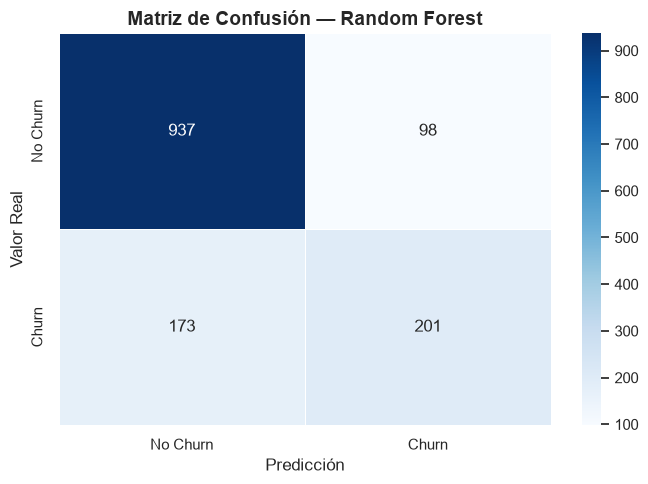

Verdaderos Negativos (TN): 937
Falsos Positivos     (FP): 98
Falsos Negativos     (FN): 173
Verdaderos Positivos (TP): 201


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=ax,
    linewidths=0.5
)
ax.set_title('Matriz de Confusión — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos     (FP): {fp}')
print(f'Falsos Negativos     (FN): {fn}')
print(f'Verdaderos Positivos (TP): {tp}')

**Interpretación:** En el contexto de predicción de churn, los **Falsos Negativos** (clientes que abandonan pero el modelo no detecta) son especialmente costosos para la empresa, ya que son oportunidades de retención perdidas.

### 6.4 Curva ROC y AUC

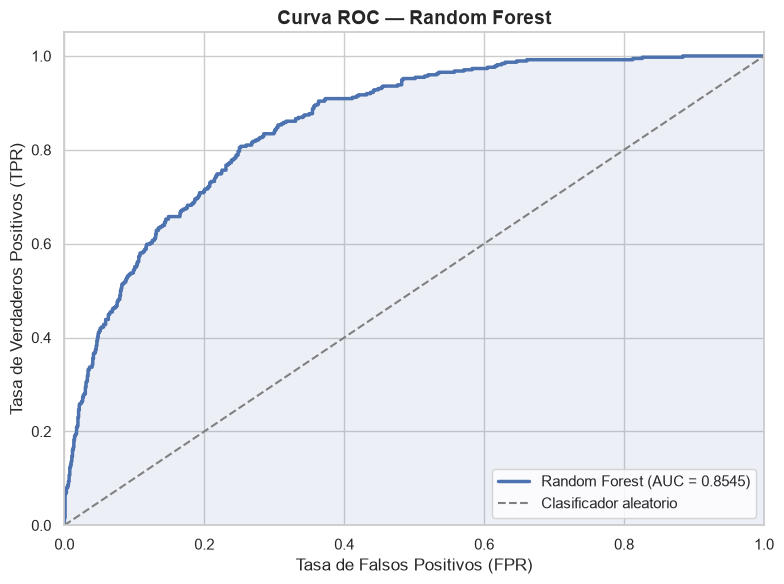

AUC-ROC: 0.8545


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#4C72B0', lw=2.5,
        label=f'Random Forest (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Clasificador aleatorio')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

**Interpretación del AUC-ROC:**
- **AUC = 0.5:** El modelo no tiene capacidad discriminativa (equivale a adivinar al azar).
- **AUC = 1.0:** Clasificación perfecta.
- **AUC > 0.85:** Generalmente considerado un buen modelo para churn prediction.

## 7. Importancia de variables (Feature Importance)

Random Forest calcula la importancia de cada variable midiendo cuánto contribuye en promedio a la reducción de impureza (índice de Gini) a lo largo de todos los árboles. Variables con mayor importancia son más determinantes para predecir el churn.

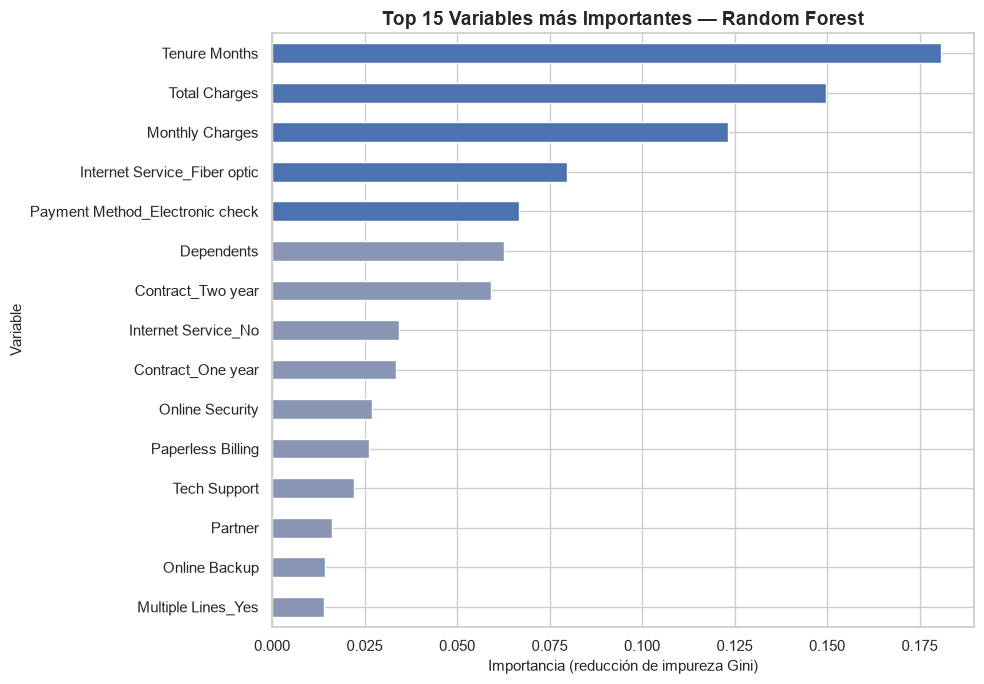

Top 15 features por importancia:
Tenure Months                      0.180677
Total Charges                      0.149593
Monthly Charges                    0.123121
Internet Service_Fiber optic       0.079809
Payment Method_Electronic check    0.066620
Dependents                         0.062656
Contract_Two year                  0.059273
Internet Service_No                0.034283
Contract_One year                  0.033490
Online Security                    0.027024
Paperless Billing                  0.026090
Tech Support                       0.022208
Partner                            0.016134
Online Backup                      0.014330
Multiple Lines_Yes                 0.014154


In [9]:
importancias = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top15 = importancias.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#4C72B0' if i < 5 else '#8896b3' for i in range(15)]
top15.sort_values().plot(
    kind='barh',
    ax=ax,
    color=colores[::-1],
    edgecolor='white'
)
ax.set_title('Top 15 Variables más Importantes — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
ax.set_ylabel('Variable', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 15 features por importancia:')
print(top15.to_string())

## 8. Resumen de resultados

### ¿Por qué Random Forest supera a un árbol simple gracias al Bagging?

Un árbol de decisión individual es un modelo de **alta varianza**: si cambiamos ligeramente los datos de entrenamiento, el árbol resultante puede ser muy diferente. Random Forest mitiga esto al:

1. **Bootstrap:** Entrenar cada árbol sobre una muestra aleatoria con reemplazo (~63% de los datos originales).
2. **Aleatorización de features:** Evaluar solo `sqrt(n_features)` variables en cada nodo, decorrelacionando los árboles.
3. **Promedio:** La predicción final es el consenso de múltiples árboles independientes.

El resultado es un modelo con **menor varianza** y **similar sesgo**, que generaliza mucho mejor a datos nuevos.

In [10]:
# Guardamos las métricas para el notebook comparativo
import json

metricas_rf = {
    'modelo': 'Random Forest',
    'accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'f1_weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
    'f1_churn':   round(f1_score(y_test, y_pred, pos_label=1), 4),
    'auc_roc':    round(roc_auc, 4),
    'mejores_params': grid_search.best_params_
}

with open('../data/processed/metricas_rf.json', 'w') as f:
    json.dump(metricas_rf, f, indent=2)

print('Métricas guardadas en data/processed/metricas_rf.json')
print(json.dumps(metricas_rf, indent=2))

Métricas guardadas en data/processed/metricas_rf.json
{
  "modelo": "Random Forest",
  "accuracy": 0.8077,
  "f1_weighted": 0.8003,
  "f1_churn": 0.5973,
  "auc_roc": 0.8545,
  "mejores_params": {
    "max_depth": 10,
    "max_features": "sqrt",
    "min_samples_split": 5,
    "n_estimators": 300
  }
}
